# Обнаружение мошенничества в банковских транзакциях - Transformer MeanMax (Тюнинг)
## Часть 1: Настройка окружения

Инициализация зависимостей, логирования и параметров визуализации.

In [9]:
import logging
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    roc_auc_score, precision_recall_curve, roc_curve,
    f1_score, fbeta_score, precision_score, recall_score,
    accuracy_score, confusion_matrix, classification_report,
    average_precision_score
)

import optuna
from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler

# Setup
warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

# PyTorch settings
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
torch.manual_seed(42)
np.random.seed(42)

# Visualization settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
logger.info(f"Окружение инициализировано. Устройство: {device}")

2026-05-11 23:14:15,905 - INFO - Окружение инициализировано. Устройство: mps


## Часть 2: Загрузка и подготовка данных

Загрузка транзакций и организация их в последовательности по клиентам.

In [10]:
from pathlib import Path

DATA_DIR = Path("../data")

df_train = pd.read_csv(DATA_DIR / "train_clean.csv", index_col=False)
df_val = pd.read_csv(DATA_DIR / "val_clean.csv", index_col=False)
df_test = pd.read_csv(DATA_DIR / "test_clean.csv", index_col=False)

logger.info(f"Тренировочный набор: {df_train.shape[0]:,} транзакций x {df_train.shape[1]} колонок")
logger.info(f"Валидационный набор: {df_val.shape[0]:,} транзакций x {df_val.shape[1]} колонок")
logger.info(f"Тестовый набор: {df_test.shape[0]:,} транзакций x {df_test.shape[1]} колонок")
logger.info(f"Доля мошенничества (тренировка): {df_train['FraudResult'].mean():.2%}")
logger.info(f"Доля мошенничества (валидация): {df_val['FraudResult'].mean():.2%}")
logger.info(f"Доля мошенничества (тест): {df_test['FraudResult'].mean():.2%}")

print("\nСводка данных:")
print(f"  Источник: {DATA_DIR}")
print(f"  Уникальных клиентов (тренировка): {df_train['CustomerId'].nunique():,}")
print(f"  Уникальных клиентов (валидация): {df_val['CustomerId'].nunique():,}")
print(f"  Уникальных клиентов (тест): {df_test['CustomerId'].nunique():,}")
print(f"  Средний размер последовательности: {len(df_train) / df_train['CustomerId'].nunique():.1f} транзакций")


2026-05-11 23:14:17,306 - INFO - Тренировочный набор: 57,364 транзакций x 24 колонок
2026-05-11 23:14:17,314 - INFO - Валидационный набор: 19,162 транзакций x 24 колонок
2026-05-11 23:14:17,320 - INFO - Тестовый набор: 19,136 транзакций x 24 колонок
2026-05-11 23:14:17,378 - INFO - Доля мошенничества (тренировка): 0.20%
2026-05-11 23:14:17,380 - INFO - Доля мошенничества (валидация): 0.21%
2026-05-11 23:14:17,382 - INFO - Доля мошенничества (тест): 0.20%



Сводка данных:
  Источник: ../data
  Уникальных клиентов (тренировка): 2,245
  Уникальных клиентов (валидация): 748
  Уникальных клиентов (тест): 749
  Средний размер последовательности: 25.6 транзакций


## Часть 3: Использование подготовленных признаков и создание последовательностей

Извлечение признаков и организация данных в последовательности для обработки трансформера.

In [11]:
import random

def reset_seeds(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


FEATURE_COLS = [
    "Amount",
    "abs_amount",
    "log_abs_amount",
    "amount_sign",
    "is_negative_amount",
    "tx_month",
    "tx_day",
    "tx_hour",
    "tx_minute",
    "tx_dayofweek",
    "tx_is_weekend",
    "tx_elapsed_seconds",
    "tx_elapsed_days",
    "tx_hour_sin",
    "tx_hour_cos",
    "tx_dayofweek_sin",
    "tx_dayofweek_cos",
    "ProviderId_id",
    "ProductId_id",
    "ProductCategory_id",
    "ChannelId_id",
    "PricingStrategy_id",
]

TARGET_COL = "FraudResult"
CLIENT_ID_COL = "CustomerId"
SORT_COLS = ["tx_elapsed_seconds", "tx_elapsed_days", "tx_month", "tx_day", "tx_hour", "tx_minute"]

train_features = df_train[[CLIENT_ID_COL, *FEATURE_COLS, TARGET_COL]].copy()
val_features = df_val[[CLIENT_ID_COL, *FEATURE_COLS, TARGET_COL]].copy()
test_features = df_test[[CLIENT_ID_COL, *FEATURE_COLS, TARGET_COL]].copy()

logger.info("Используются признаки, подготовленные в data/cleanup.ipynb")
logger.info(f"Признаков в последовательности: {len(FEATURE_COLS)}")
logger.info(f"Колонки сортировки транзакций: {SORT_COLS}")


2026-05-11 23:14:18,071 - INFO - Используются признаки, подготовленные в data/cleanup.ipynb
2026-05-11 23:14:18,073 - INFO - Признаков в последовательности: 22
2026-05-11 23:14:18,079 - INFO - Колонки сортировки транзакций: ['tx_elapsed_seconds', 'tx_elapsed_days', 'tx_month', 'tx_day', 'tx_hour', 'tx_minute']


### Создание последовательностей для каждого клиента

In [12]:
def create_client_sequences(df, max_seq_len=100, feature_cols=None):
    """
    Организация транзакций в последовательности по клиентам.
    Транзакции внутри каждого клиента сортируются по времени перед обрезкой.
    """
    if feature_cols is None:
        feature_cols = FEATURE_COLS

    sequences = []
    labels = []
    client_ids = []

    available_sort_cols = [col for col in SORT_COLS if col in df.columns]

    for account_id, group in df.groupby(CLIENT_ID_COL, sort=False):
        if available_sort_cols:
            group = group.sort_values(available_sort_cols, kind="mergesort")

        seq = group[feature_cols].values.astype(np.float32)

        if len(seq) > max_seq_len:
            seq = seq[-max_seq_len:]

        if len(seq) < max_seq_len:
            padding = np.zeros((max_seq_len - len(seq), seq.shape[1]), dtype=np.float32)
            seq = np.vstack([padding, seq])

        label = int(group[TARGET_COL].max())

        sequences.append(seq)
        labels.append(label)
        client_ids.append(account_id)

    return np.array(sequences), np.array(labels), np.array(client_ids), list(feature_cols)


logger.info("Создание последовательностей клиентов...")
train_sequences, train_labels, train_clients, feature_cols = create_client_sequences(
    train_features,
    feature_cols=FEATURE_COLS,
)
val_sequences, val_labels, val_clients, _ = create_client_sequences(
    val_features,
    feature_cols=feature_cols,
)
test_sequences, test_labels, test_clients, _ = create_client_sequences(
    test_features,
    feature_cols=feature_cols,
)

logger.info(f"Тренировочные последовательности: {train_sequences.shape}")
logger.info(f"Валидационные последовательности: {val_sequences.shape}")
logger.info(f"Тестовые последовательности: {test_sequences.shape}")
logger.info(f"Распределение меток (тренировка): {np.bincount(train_labels)}")
logger.info(f"Распределение меток (валидация): {np.bincount(val_labels)}")
logger.info(f"Распределение меток (тест): {np.bincount(test_labels)}")
logger.info(f"Всего признаков в последовательности: {len(feature_cols)}")

print(f"\nРазмер последовательностей:")
print(f"  Максимальная длина: 100 транзакций")
print(f"  Размер признаков: {train_sequences.shape[2]}")
print(f"  Клиентов (тренировка): {len(train_sequences)}")
print(f"  Клиентов (валидация): {len(val_sequences)}")
print(f"  Клиентов (тест): {len(test_sequences)}")


2026-05-11 23:14:18,209 - INFO - Создание последовательностей клиентов...
2026-05-11 23:14:29,782 - INFO - Тренировочные последовательности: (2245, 100, 22)
2026-05-11 23:14:29,791 - INFO - Валидационные последовательности: (748, 100, 22)
2026-05-11 23:14:29,795 - INFO - Тестовые последовательности: (749, 100, 22)
2026-05-11 23:14:29,798 - INFO - Распределение меток (тренировка): [2213   32]
2026-05-11 23:14:29,800 - INFO - Распределение меток (валидация): [737  11]
2026-05-11 23:14:29,801 - INFO - Распределение меток (тест): [738  11]
2026-05-11 23:14:29,803 - INFO - Всего признаков в последовательности: 22



Размер последовательностей:
  Максимальная длина: 100 транзакций
  Размер признаков: 22
  Клиентов (тренировка): 2245
  Клиентов (валидация): 748
  Клиентов (тест): 749


### Нормализация признаков

In [13]:
n_clients, seq_len, n_features = train_sequences.shape
training_reshaped = train_sequences.reshape(-1, n_features)

scaler = StandardScaler()
training_scaled_reshaped = scaler.fit_transform(training_reshaped)
training_sequences_scaled = training_scaled_reshaped.reshape(n_clients, seq_len, n_features)

val_reshaped = val_sequences.reshape(-1, n_features)
val_scaled_reshaped = scaler.transform(val_reshaped)
val_sequences_scaled = val_scaled_reshaped.reshape(val_sequences.shape[0], seq_len, n_features)

test_reshaped = test_sequences.reshape(-1, n_features)
test_scaled_reshaped = scaler.transform(test_reshaped)
test_sequences_scaled = test_scaled_reshaped.reshape(test_sequences.shape[0], seq_len, n_features)

logger.info("Признаки нормализованы")
print(f"Нормализация - Статистика тренировки:")
print(f"  Mean: {training_sequences_scaled.reshape(-1, n_features).mean(axis=0)[:5]}...")
print(f"  Std:  {training_sequences_scaled.reshape(-1, n_features).std(axis=0)[:5]}...")

2026-05-11 23:14:30,645 - INFO - Признаки нормализованы


Нормализация - Статистика тренировки:
  Mean: [-4.3345003e-06 -2.5165941e-06 -9.7838507e-05 -5.6253055e-05
  1.5194544e-04]...
  Std:  [0.9996615 0.9996004 1.0007588 1.0006154 0.9976402]...


### Преобразование в PyTorch tensors

In [14]:
X_train_tensor = torch.FloatTensor(training_sequences_scaled)
y_train_tensor = torch.LongTensor(train_labels)

X_val_tensor = torch.FloatTensor(val_sequences_scaled)
y_val_tensor = torch.LongTensor(val_labels)

X_test_tensor = torch.FloatTensor(test_sequences_scaled)
y_test_tensor = torch.LongTensor(test_labels)

logger.info(f"Тренировочные тензоры: {X_train_tensor.shape}")
logger.info(f"Валидационные тензоры: {X_val_tensor.shape}")
logger.info(f"Тестовые тензоры: {X_test_tensor.shape}")

2026-05-11 23:14:30,715 - INFO - Тренировочные тензоры: torch.Size([2245, 100, 22])
2026-05-11 23:14:30,716 - INFO - Валидационные тензоры: torch.Size([748, 100, 22])
2026-05-11 23:14:30,717 - INFO - Тестовые тензоры: torch.Size([749, 100, 22])


## Часть 4: Архитектура модели Transformer MeanMax для последовательностей

In [15]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer("pe", pe)

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]


class TransformerMeanMaxClassifier(nn.Module):
    """
    Улучшенный классификатор на основе Transformer Encoder для последовательностей транзакций.
    Идея:
    - проекция входа
    - positional encoding
    - transformer encoder
    - mean pooling
    - max pooling
    - усиленная classifier head
    """
    def __init__(
        self,
        input_dim,
        d_model=64,
        nhead=4,
        num_layers=2,
        dim_feedforward=128,
        num_classes=2,
        dropout=0.3
    ):
        super().__init__()

        self.input_proj = nn.Sequential(
            nn.Linear(input_dim, d_model),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        self.pos_encoder = PositionalEncoding(d_model, max_len=1000)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
            norm_first=True,
            activation="gelu"
        )

        self.encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )

        self.layer_norm = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

        combined_dim = d_model * 2

        self.classifier = nn.Sequential(
            nn.Linear(combined_dim, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, num_classes)
        )

    def forward(self, x):
        x = self.input_proj(x)
        x = self.pos_encoder(x)
        x = self.encoder(x)
        x = self.layer_norm(x)

        mean_pooled = torch.mean(x, dim=1)
        max_pooled, _ = torch.max(x, dim=1)

        features = torch.cat([mean_pooled, max_pooled], dim=1)
        features = self.dropout(features)
        logits = self.classifier(features)
        return logits


# ==================== FOCAL LOSS ====================

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        log_probs = F.log_softmax(inputs, dim=1)
        probs = torch.exp(log_probs)

        targets = targets.view(-1, 1)

        log_pt = log_probs.gather(1, targets).squeeze(1)
        pt = probs.gather(1, targets).squeeze(1)

        if self.alpha is not None:
            at = self.alpha.gather(0, targets.squeeze(1))
            loss = -at * ((1 - pt) ** self.gamma) * log_pt
        else:
            loss = -((1 - pt) ** self.gamma) * log_pt

        if self.reduction == 'mean':
            return loss.mean()
        elif self.reduction == 'sum':
            return loss.sum()
        else:
            return loss

## Часть 5: Обучение модели

Обучение классификатора Transformer MeanMax с ранней остановкой и мониторингом валидации.

In [16]:
def train_epoch(model, train_loader, optimizer, criterion, device, clip_grad=1.0):
    """Обучение на одной эпохе с mini-batches."""
    model.train()
    total_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()

        if clip_grad > 0:
            nn.utils.clip_grad_norm_(model.parameters(), clip_grad)

        optimizer.step()
        total_loss += loss.item() * X_batch.size(0)

    return total_loss / len(train_loader.dataset)


def validate(model, val_loader, criterion, device):
    """Валидация модели."""
    model.eval()
    total_loss = 0.0
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            total_loss += loss.item() * X_batch.size(0)

            probs = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
            labels = y_batch.cpu().numpy()

            all_probs.extend(probs)
            all_labels.extend(labels)

    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)
    pr_auc = average_precision_score(all_labels, all_probs)

    return total_loss / len(val_loader.dataset), pr_auc


logger.info("Начало расширенного подбора гиперпараметров с Optuna...")


def predict_on_loader(model, data_loader, device):
    model.eval()
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch)
            probs = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()

            all_probs.extend(probs)
            all_labels.extend(y_batch.cpu().numpy())

    return np.array(all_labels), np.array(all_probs)


def find_best_threshold(y_true, y_score, beta=0.5):
    thresholds = np.arange(0.0, 1.01, 0.01)
    fbeta_scores = []

    for thresh in thresholds:
        y_pred = (y_score >= thresh).astype(int)
        score = fbeta_score(y_true, y_pred, beta=beta, zero_division=0)
        fbeta_scores.append(score)

    best_idx = int(np.argmax(fbeta_scores))
    best_threshold = thresholds[best_idx]
    best_score = fbeta_scores[best_idx]

    return best_threshold, best_score


def objective(trial):
    reset_seeds(42)

    d_model = trial.suggest_categorical('d_model', [32, 64, 96, 128, 160, 192, 256])
    nhead = trial.suggest_categorical('nhead', [2, 4, 8])
    num_layers = trial.suggest_int('num_layers', 1, 5)
    dim_feedforward = trial.suggest_categorical('dim_feedforward', [128, 256, 384, 512, 768, 1024])
    dropout = trial.suggest_float('dropout', 0.1, 0.5, step=0.1)

    learning_rate = trial.suggest_float('learning_rate', 1e-5, 5e-3, log=True)
    weight_decay = trial.suggest_float('weight_decay', 1e-7, 1e-2, log=True)
    optimizer_type = trial.suggest_categorical('optimizer_type', ['adam', 'adamw', 'sgd'])

    criterion_type = trial.suggest_categorical('criterion_type', ['ce', 'weighted_ce', 'focal'])
    scheduler_type = trial.suggest_categorical('scheduler_type', ['none', 'step', 'cosine'])
    batch_size = trial.suggest_categorical('batch_size', [16, 32, 64, 128])
    clip_grad = trial.suggest_float('clip_grad', 0.5, 2.0, step=0.5)

    num_epochs = 120

    model_optuna = TransformerMeanMaxClassifier(
        input_dim=n_features,
        d_model=d_model,
        nhead=nhead,
        num_layers=num_layers,
        dim_feedforward=dim_feedforward,
        num_classes=2,
        dropout=dropout
    ).to(device)

    if criterion_type == 'ce':
        criterion = nn.CrossEntropyLoss()

    elif criterion_type == 'weighted_ce':
        fraud_weight = trial.suggest_float('fraud_weight', 2.0, 25.0)
        class_weights = torch.tensor([1.0, fraud_weight], dtype=torch.float32).to(device)
        criterion = nn.CrossEntropyLoss(weight=class_weights)

    else:
        alpha_fraud = trial.suggest_float('alpha_fraud', 2.0, 25.0)
        gamma = trial.suggest_float('gamma', 1.0, 5.0)
        alpha = torch.tensor([1.0, alpha_fraud], dtype=torch.float32).to(device)
        criterion = FocalLoss(alpha=alpha, gamma=gamma)

    if optimizer_type == 'adam':
        optimizer = optim.Adam(
            model_optuna.parameters(),
            lr=learning_rate,
            weight_decay=weight_decay
        )
    elif optimizer_type == 'adamw':
        optimizer = optim.AdamW(
            model_optuna.parameters(),
            lr=learning_rate,
            weight_decay=weight_decay
        )
    else:
        momentum = trial.suggest_float('momentum', 0.8, 0.99)
        optimizer = optim.SGD(
            model_optuna.parameters(),
            lr=learning_rate,
            momentum=momentum,
            weight_decay=weight_decay
        )

    if scheduler_type == 'step':
        scheduler = optim.lr_scheduler.StepLR(
            optimizer,
            step_size=10,
            gamma=0.5
        )
    elif scheduler_type == 'cosine':
        scheduler = optim.lr_scheduler.CosineAnnealingLR(
            optimizer,
            T_max=60,
            eta_min=1e-6
        )
    else:
        scheduler = None

    train_loader = DataLoader(
        TensorDataset(X_train_tensor, y_train_tensor),
        batch_size=batch_size,
        shuffle=True
    )
    val_loader = DataLoader(
        TensorDataset(X_val_tensor, y_val_tensor),
        batch_size=batch_size,
        shuffle=False
    )

    patience = 12
    best_val_f05 = 0.0
    patience_counter = 0

    for epoch in range(num_epochs):
        train_loss = train_epoch(
            model_optuna,
            train_loader,
            optimizer,
            criterion,
            device,
            clip_grad=clip_grad
        )
        val_loss, val_pr_auc = validate(model_optuna, val_loader, criterion, device)

        y_val_true, y_val_score = predict_on_loader(model_optuna, val_loader, device)
        best_threshold_epoch, val_f05_epoch = find_best_threshold(
            y_val_true,
            y_val_score,
            beta=0.5
        )

        if scheduler is not None:
            scheduler.step()

        trial.report(val_f05_epoch, step=epoch)

        if trial.should_prune():
            raise optuna.TrialPruned()

        if val_f05_epoch > best_val_f05:
            best_val_f05 = val_f05_epoch
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break

    return best_val_f05


# ===== Create Study and Optimize =====
sampler = TPESampler(seed=42)
pruner = MedianPruner(n_startup_trials=8, n_warmup_steps=12)

study = optuna.create_study(
    direction='maximize',
    sampler=sampler,
    pruner=pruner,
    study_name='transformer_meanmax_fraud_detection_tuning'
)

n_trials = 50
study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

# ===== Best Trial =====
best_trial = study.best_trial
best_params = best_trial.params
clip_grad = best_params.get('clip_grad', 1.0)

logger.info(f"\n{'=' * 80}")
logger.info(f"Подбор гиперпараметров завершен за {len(study.trials)} trials")
logger.info(f"Лучший F0.5 на валидации: {best_trial.value:.4f}")
logger.info(f"\nОптимальные гиперпараметры:")
for key, value in sorted(best_params.items()):
    if isinstance(value, float):
        logger.info(f"  {key:<20} = {value:.6f}")
    else:
        logger.info(f"  {key:<20} = {value}")
logger.info(f"{'=' * 80}")


# ===== Train Best Model =====
reset_seeds(42)
logger.info("\nОбучение лучшей модели на train с контролем по val...")

model = TransformerMeanMaxClassifier(
    input_dim=n_features,
    d_model=best_params['d_model'],
    nhead=best_params['nhead'],
    num_layers=best_params['num_layers'],
    dim_feedforward=best_params['dim_feedforward'],
    num_classes=2,
    dropout=best_params['dropout']
).to(device)

criterion_type = best_params['criterion_type']

if criterion_type == 'ce':
    criterion = nn.CrossEntropyLoss()

elif criterion_type == 'weighted_ce':
    class_weights = torch.tensor(
        [1.0, best_params['fraud_weight']],
        dtype=torch.float32
    ).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights)

else:
    alpha = torch.tensor(
        [1.0, best_params['alpha_fraud']],
        dtype=torch.float32
    ).to(device)
    criterion = FocalLoss(alpha=alpha, gamma=best_params['gamma'])

if best_params['optimizer_type'] == 'adam':
    optimizer = optim.Adam(
        model.parameters(),
        lr=best_params['learning_rate'],
        weight_decay=best_params['weight_decay']
    )

elif best_params['optimizer_type'] == 'adamw':
    optimizer = optim.AdamW(
        model.parameters(),
        lr=best_params['learning_rate'],
        weight_decay=best_params['weight_decay']
    )

else:
    optimizer = optim.SGD(
        model.parameters(),
        lr=best_params['learning_rate'],
        momentum=best_params['momentum'],
        weight_decay=best_params['weight_decay']
    )

if best_params['scheduler_type'] == 'step':
    scheduler = optim.lr_scheduler.StepLR(
        optimizer,
        step_size=10,
        gamma=0.5
    )
elif best_params['scheduler_type'] == 'cosine':
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=60,
        eta_min=1e-6
    )
else:
    scheduler = None

train_loader = DataLoader(
    TensorDataset(X_train_tensor, y_train_tensor),
    batch_size=best_params['batch_size'],
    shuffle=True
)

val_loader = DataLoader(
    TensorDataset(X_val_tensor, y_val_tensor),
    batch_size=best_params['batch_size'],
    shuffle=False
)

num_epochs = 100
best_val_f05 = 0.0
best_threshold_on_val = 0.5
patience_counter = 0
best_state_dict = None
patience = 15

train_losses = []
val_losses = []
val_pr_aucs = []
val_f05_scores = []
learning_rates = []

for epoch in range(num_epochs):
    train_loss = train_epoch(
        model,
        train_loader,
        optimizer,
        criterion,
        device,
        clip_grad=clip_grad
    )
    val_loss, val_pr_auc = validate(model, val_loader, criterion, device)

    y_val_true_epoch, y_val_score_epoch = predict_on_loader(model, val_loader, device)
    val_threshold_epoch, val_f05_epoch = find_best_threshold(
        y_val_true_epoch,
        y_val_score_epoch,
        beta=0.5
    )

    if scheduler is not None:
        scheduler.step()

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_pr_aucs.append(val_pr_auc)
    val_f05_scores.append(val_f05_epoch)
    learning_rates.append(optimizer.param_groups[0]['lr'])

    if (epoch + 1) % 10 == 0:
        lr = optimizer.param_groups[0]['lr']
        logger.info(
            f"Эпоха {epoch + 1:3d}: "
            f"train_loss={train_loss:.4f}, "
            f"val_loss={val_loss:.4f}, "
            f"val_pr_auc={val_pr_auc:.4f}, "
            f"val_f0.5={val_f05_epoch:.4f}, "
            f"lr={lr:.6f}"
        )

    if val_f05_epoch > best_val_f05:
        best_val_f05 = val_f05_epoch
        best_threshold_on_val = val_threshold_epoch
        patience_counter = 0
        best_state_dict = {k: v.cpu().clone() for k, v in model.state_dict().items()}
    else:
        patience_counter += 1
        if patience_counter >= patience:
            logger.info(f"Ранняя остановка на эпохе {epoch + 1}")
            break

if best_state_dict is not None:
    model.load_state_dict(best_state_dict)
    model.to(device)

logger.info(f"Обучение завершено. Лучший F0.5 валидации: {best_val_f05:.4f}")
logger.info(f"Лучший порог по валидации: {best_threshold_on_val:.2f}")

2026-05-11 23:14:30,875 - INFO - Начало расширенного подбора гиперпараметров с Optuna...


[I 2026-05-11 23:14:30,934] A new study created in memory with name: transformer_meanmax_fraud_detection_tuning
Best trial: 0. Best value: 0.851064:   2%|▏         | 1/50 [00:54<44:42, 54.74s/it]

[I 2026-05-11 23:15:25,703] Trial 0 finished with value: 0.851063829787234 and parameters: {'d_model': 64, 'nhead': 2, 'num_layers': 1, 'dim_feedforward': 128, 'dropout': 0.30000000000000004, 'learning_rate': 0.0001464895513280072, 'weight_decay': 2.8585493941961903e-06, 'optimizer_type': 'adam', 'criterion_type': 'focal', 'scheduler_type': 'cosine', 'batch_size': 32, 'clip_grad': 2.0, 'alpha_fraud': 24.209536760714865, 'gamma': 4.233589392465845}. Best is trial 0 with value: 0.851063829787234.


Best trial: 1. Best value: 0.897436:   4%|▍         | 2/50 [01:56<47:17, 59.12s/it]

[I 2026-05-11 23:16:27,517] Trial 1 finished with value: 0.8974358974358975 and parameters: {'d_model': 96, 'nhead': 2, 'num_layers': 2, 'dim_feedforward': 512, 'dropout': 0.5, 'learning_rate': 0.00041087915453240814, 'weight_decay': 0.004067908494359549, 'optimizer_type': 'adamw', 'criterion_type': 'weighted_ce', 'scheduler_type': 'none', 'batch_size': 64, 'clip_grad': 2.0, 'fraud_weight': 19.76162969382312}. Best is trial 1 with value: 0.8974358974358975.


...

Best trial: 4. Best value: 0.930233:  98%|█████████▊| 49/50 [2:00:49<02:01, 121.71s/it]

[I 2026-05-12 01:15:19,844] Trial 48 pruned. 


Best trial: 4. Best value: 0.930233: 100%|██████████| 50/50 [2:02:16<00:00, 146.74s/it]
2026-05-12 01:16:47,890 - INFO - 
2026-05-12 01:16:47,927 - INFO - Подбор гиперпараметров завершен за 50 trials
2026-05-12 01:16:47,929 - INFO - Лучший F0.5 на валидации: 0.9302
2026-05-12 01:16:47,931 - INFO - 
Оптимальные гиперпараметры:
2026-05-12 01:16:47,932 - INFO -   batch_size           = 16
2026-05-12 01:16:47,933 - INFO -   clip_grad            = 1.500000
2026-05-12 01:16:47,933 - INFO -   criterion_type       = weighted_ce
2026-05-12 01:16:47,933 - INFO -   d_model              = 192
2026-05-12 01:16:47,934 - INFO -   dim_feedforward      = 384
2026-05-12 01:16:47,934 - INFO -   dropout              = 0.200000
2026-05-12 01:16:47,935 - INFO -   fraud_weight         = 6.010428
2026-05-12 01:16:47,935 - INFO -   learning_rate        = 0.000923
2026-05-12 01:16:47,935 - INFO -   nhead                = 8
2026-05-12 01:16:47,936 - INFO -   num_layers           = 2
2026-05-12 01:16:47,936 - INF

[I 2026-05-12 01:16:47,829] Trial 49 finished with value: 0.851063829787234 and parameters: {'d_model': 32, 'nhead': 4, 'num_layers': 4, 'dim_feedforward': 1024, 'dropout': 0.30000000000000004, 'learning_rate': 0.002425407238103032, 'weight_decay': 6.20122226586074e-05, 'optimizer_type': 'adamw', 'criterion_type': 'weighted_ce', 'scheduler_type': 'step', 'batch_size': 64, 'clip_grad': 1.5, 'fraud_weight': 2.0820078182405517}. Best is trial 4 with value: 0.9302325581395349.


2026-05-12 01:17:54,836 - INFO - Эпоха  10: train_loss=0.0335, val_loss=0.0948, val_pr_auc=0.9564, val_f0.5=0.8571, lr=0.000862
2026-05-12 01:20:58,979 - INFO - Эпоха  20: train_loss=0.0385, val_loss=0.0898, val_pr_auc=0.9005, val_f0.5=0.8974, lr=0.000693
2026-05-12 01:22:18,601 - INFO - Эпоха  30: train_loss=0.0273, val_loss=0.2156, val_pr_auc=0.8125, val_f0.5=0.8182, lr=0.000462
2026-05-12 01:23:11,153 - INFO - Ранняя остановка на эпохе 37
2026-05-12 01:23:11,288 - INFO - Обучение завершено. Лучший F0.5 валидации: 0.9302
2026-05-12 01:23:11,290 - INFO - Лучший порог по валидации: 0.84


## Часть 6: Инференс и оценка модели

Генерация предсказаний и расчет метрик качества с оптимальным порогом.

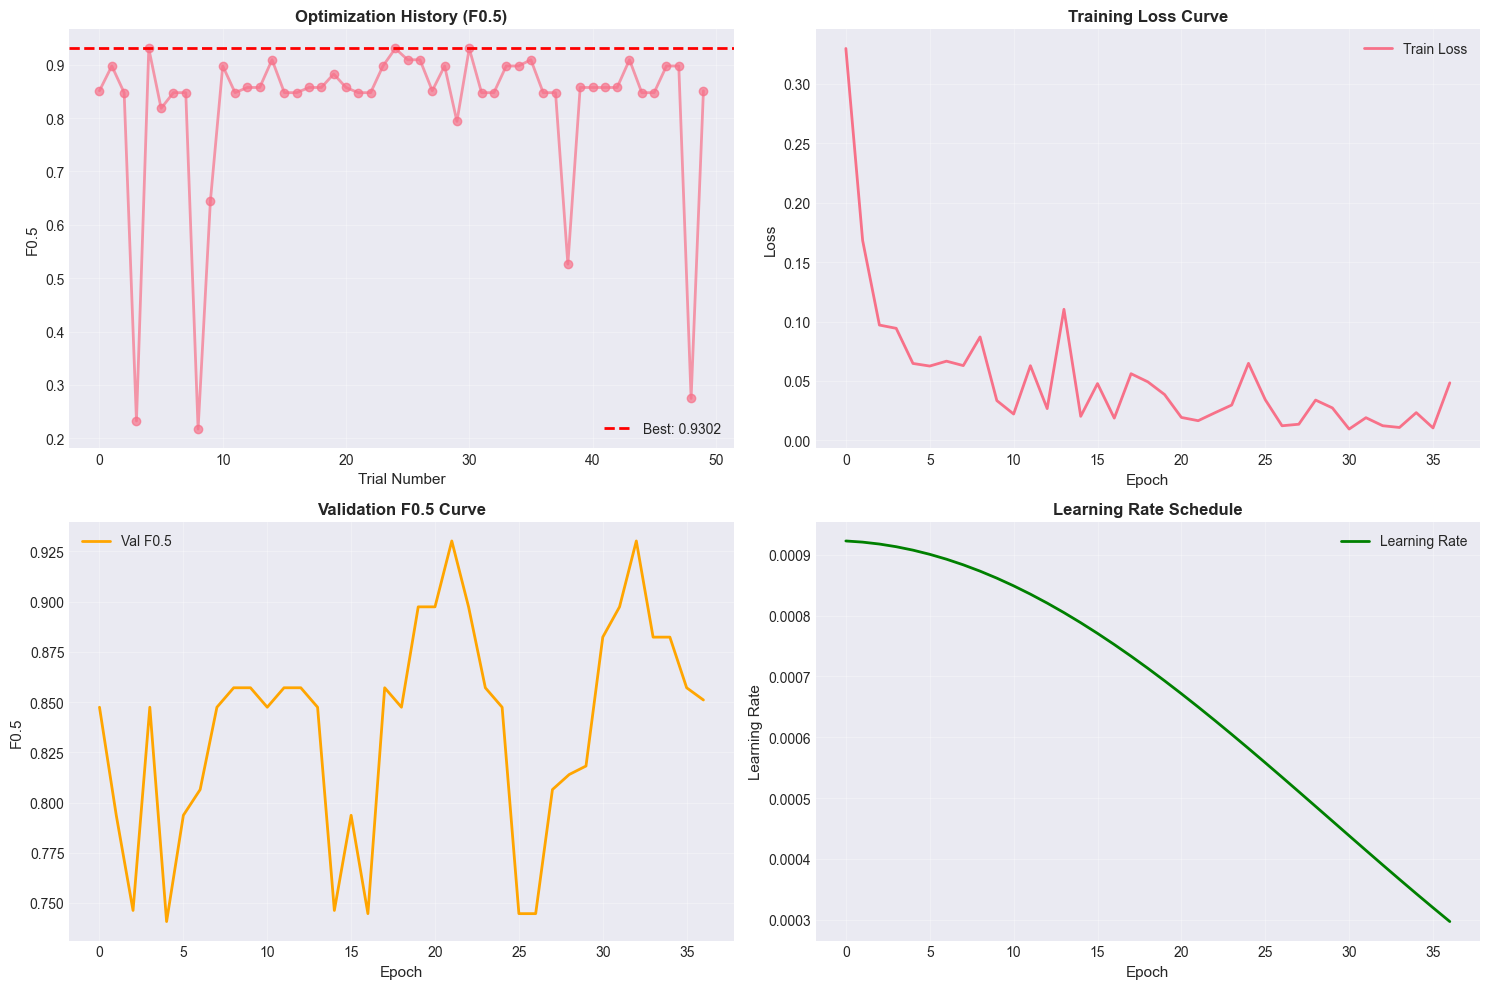

2026-05-12 01:23:13,297 - INFO - Визуализация истории оптимизации завершена
2026-05-12 01:23:15,248 - INFO - Предсказания получены для 749 клиентов
2026-05-12 01:23:15,251 - INFO - Статистика скоров - Min: 0.000000, Max: 0.960064, Mean: 0.015173
2026-05-12 01:23:15,253 - INFO - Оптимальный порог по validation: 0.84 (лучший F0.5: 0.9302)



    ОТЧЕТ ОБ ОЦЕНКЕ МОДЕЛИ TRANSFORMER MEANMAX (РАСШИРЕННЫЙ ПОДБОР - OPTUNA)    

ТЕМПЛАТА ОПТИМАЛЬНОЙ КОНФИГУРАЦИИ:
--------------------------------------------------------------------------------
  Архитектура: d_model=192, nhead=8, num_layers=2, dim_feedforward=384
  Оптимизатор: ADAMW (lr=0.000923)
  Scheduler: COSINE
  Batch size: 16
  Dropout: 0.2
  Clip grad: 1.5

СТАТИСТИКА НАБОРА ДАННЫХ:
--------------------------------------------------------------------------------
  Всего клиентов:                       749    (100.0%)
  Мошенники:                             11    (  1.5%)
  Честные:                              738    ( 98.5%)

РАСПРЕДЕЛЕНИЕ ПРЕДСКАЗАНИЙ:
--------------------------------------------------------------------------------
  Предсказано как мошенник:             10    (  1.3%)
  Предсказано как честный:             739    ( 98.7%)
  Оптимальный порог:                 0.8400

МАТРИЦА ОШИБОК:
---------------------------------------------------------------------

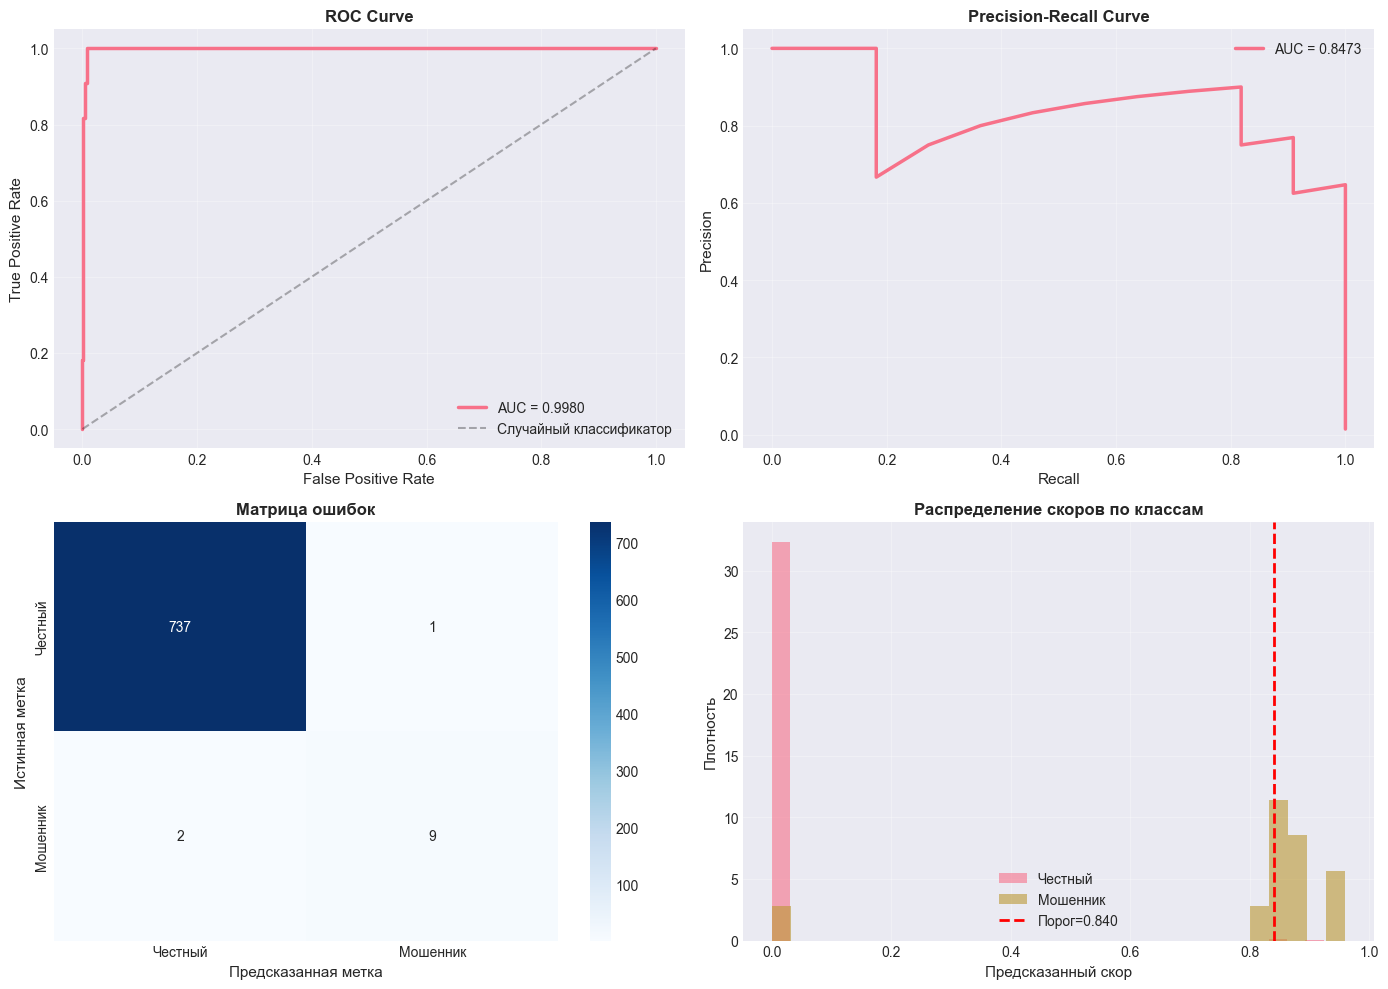

2026-05-12 01:23:16,006 - INFO - Оценка модели завершена успешно


In [17]:
# ===== Visualization of Optimization =====
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

trials_df = study.trials_dataframe()

axes[0, 0].plot(
    trials_df['number'],
    trials_df['value'],
    'o-',
    linewidth=2,
    markersize=6,
    alpha=0.7
)
axes[0, 0].axhline(
    y=best_trial.value,
    color='r',
    linestyle='--',
    linewidth=2,
    label=f'Best: {best_trial.value:.4f}'
)
axes[0, 0].set_xlabel('Trial Number', fontsize=11)
axes[0, 0].set_ylabel('F0.5', fontsize=11)
axes[0, 0].set_title('Optimization History (F0.5)', fontsize=12, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

axes[0, 1].plot(train_losses, linewidth=2, label='Train Loss')
axes[0, 1].set_xlabel('Epoch', fontsize=11)
axes[0, 1].set_ylabel('Loss', fontsize=11)
axes[0, 1].set_title('Training Loss Curve', fontsize=12, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

axes[1, 0].plot(val_f05_scores, linewidth=2, color='orange', label='Val F0.5')
axes[1, 0].set_xlabel('Epoch', fontsize=11)
axes[1, 0].set_ylabel('F0.5', fontsize=11)
axes[1, 0].set_title('Validation F0.5 Curve', fontsize=12, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

axes[1, 1].plot(learning_rates, linewidth=2, color='green', label='Learning Rate')
axes[1, 1].set_xlabel('Epoch', fontsize=11)
axes[1, 1].set_ylabel('Learning Rate', fontsize=11)
axes[1, 1].set_title('Learning Rate Schedule', fontsize=12, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

logger.info("Визуализация истории оптимизации завершена")


# ===== INFERENCE ON FULL TEST SET =====
model.eval()
all_y_pred_proba = []
all_y_true = []

test_loader = DataLoader(
    TensorDataset(X_test_tensor, y_test_tensor),
    batch_size=best_params['batch_size'],
    shuffle=False
)

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        logits = model(X_batch)
        probs = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
        all_y_pred_proba.extend(probs)
        all_y_true.extend(y_batch.cpu().numpy())

y_pred_proba = np.array(all_y_pred_proba)
y_true = np.array(all_y_true)
y_score = y_pred_proba

logger.info(f"Предсказания получены для {len(y_pred_proba)} клиентов")
logger.info(f"Статистика скоров - Min: {y_score.min():.6f}, Max: {y_score.max():.6f}, Mean: {y_score.mean():.6f}")

optimal_thresh = best_threshold_on_val
y_pred = (y_score >= optimal_thresh).astype(int)

logger.info(f"Оптимальный порог по validation: {optimal_thresh:.2f} (лучший F0.5: {best_val_f05:.4f})")

tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

metrics = {
    'ROC-AUC': roc_auc_score(y_true, y_score),
    'PR-AUC': average_precision_score(y_true, y_score),
    'Accuracy': accuracy_score(y_true, y_pred),
    'Precision': precision_score(y_true, y_pred, zero_division=0),
    'Recall': recall_score(y_true, y_pred, zero_division=0),
    'F1': f1_score(y_true, y_pred, zero_division=0),
    'F0.5': fbeta_score(y_true, y_pred, beta=0.5, zero_division=0),
    'Specificity': tn / (tn + fp) if (tn + fp) > 0 else 0.0,
    'FPR': fp / (fp + tn) if (fp + tn) > 0 else 0.0,
    'FNR': fn / (fn + tp) if (fn + tp) > 0 else 0.0,
    'NPV': tn / (tn + fn) if (tn + fn) > 0 else 0.0,
}

print("\n" + "=" * 80)
print("ОТЧЕТ ОБ ОЦЕНКЕ МОДЕЛИ TRANSFORMER MEANMAX (РАСШИРЕННЫЙ ПОДБОР - OPTUNA)".center(80))
print("=" * 80)

print("\nТЕМПЛАТА ОПТИМАЛЬНОЙ КОНФИГУРАЦИИ:")
print("-" * 80)
print(
    f"  Архитектура: d_model={best_params['d_model']}, nhead={best_params['nhead']}, "
    f"num_layers={best_params['num_layers']}, dim_feedforward={best_params['dim_feedforward']}"
)
print(f"  Оптимизатор: {best_params['optimizer_type'].upper()} (lr={best_params['learning_rate']:.6f})")
print(f"  Scheduler: {best_params['scheduler_type'].upper()}")
print(f"  Batch size: {best_params['batch_size']}")
print(f"  Dropout: {best_params['dropout']}")
print(f"  Clip grad: {clip_grad}")

print("\nСТАТИСТИКА НАБОРА ДАННЫХ:")
print("-" * 80)
n_total = len(y_true)
n_fraud = (y_true == 1).sum()
n_nonfraud = (y_true == 0).sum()
print(f"  Всего клиентов:                {n_total:>10,}    ({100.0:>5.1f}%)")
print(f"  Мошенники:                     {n_fraud:>10,}    ({100*n_fraud/n_total:>5.1f}%)")
print(f"  Честные:                       {n_nonfraud:>10,}    ({100*n_nonfraud/n_total:>5.1f}%)")

print("\nРАСПРЕДЕЛЕНИЕ ПРЕДСКАЗАНИЙ:")
print("-" * 80)
n_pred_fraud = (y_pred == 1).sum()
n_pred_legit = (y_pred == 0).sum()
print(f"  Предсказано как мошенник:     {n_pred_fraud:>10,}    ({100*n_pred_fraud/n_total:>5.1f}%)")
print(f"  Предсказано как честный:      {n_pred_legit:>10,}    ({100*n_pred_legit/n_total:>5.1f}%)")
print(f"  Оптимальный порог:             {optimal_thresh:>10.4f}")

print("\nМАТРИЦА ОШИБОК:")
print("-" * 80)
print(f"  Истинные негативы (TN):        {tn:>10,}")
print(f"  Ложные позитивы (FP):          {fp:>10,}")
print(f"  Ложные негативы (FN):          {fn:>10,}")
print(f"  Истинные позитивы (TP):        {tp:>10,}")

print("\nМЕТРИКИ КАЧЕСТВА:")
print("-" * 80)
for metric_name, metric_value in sorted(metrics.items()):
    print(f"  {metric_name:<25} {metric_value:>10.4f}")

print("\nДЕТАЛЬНЫЙ ОТЧЕТ КЛАССИФИКАЦИИ:")
print("-" * 80)
print(classification_report(y_true, y_pred, target_names=['Честный', 'Мошенник'], 
                          digits=4, zero_division=0))

print("ПАРИТЕТ ПО БАКЕТАМ СКОРА (интервалы 0.1):")
print("-" * 80)
buckets = pd.cut(y_score, bins=10, labels=[f"{i*0.1:.1f}-{(i+1)*0.1:.1f}" for i in range(10)])
parity_df = pd.DataFrame({
    'bucket': buckets,
    'y_true': y_true,
    'y_score': y_score
})

parity_stats = parity_df.groupby('bucket', observed=True).agg({
    'y_true': ['count', 'sum', 'mean'],
    'y_score': ['min', 'max', 'mean']
}).round(4)

parity_stats.columns = ['count', 'fraud_count', 'fraud_rate', 'score_min', 'score_max', 'score_mean']
print(parity_stats.to_string())

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

fpr, tpr, roc_thresholds = roc_curve(y_true, y_score)
axes[0, 0].plot(fpr, tpr, linewidth=2.5, label=f'AUC = {metrics["ROC-AUC"]:.4f}')
axes[0, 0].plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Случайный классификатор')
axes[0, 0].set_xlabel('False Positive Rate', fontsize=11)
axes[0, 0].set_ylabel('True Positive Rate', fontsize=11)
axes[0, 0].set_title('ROC Curve', fontsize=12, fontweight='bold')
axes[0, 0].legend(loc='lower right')
axes[0, 0].grid(alpha=0.3)

precision_vals, recall_vals, _ = precision_recall_curve(y_true, y_score)
axes[0, 1].plot(recall_vals, precision_vals, linewidth=2.5, label=f'AUC = {metrics["PR-AUC"]:.4f}')
axes[0, 1].set_xlabel('Recall', fontsize=11)
axes[0, 1].set_ylabel('Precision', fontsize=11)
axes[0, 1].set_title('Precision-Recall Curve', fontsize=12, fontweight='bold')
axes[0, 1].legend(loc='best')
axes[0, 1].grid(alpha=0.3)

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1, 0],
           xticklabels=['Честный', 'Мошенник'],
           yticklabels=['Честный', 'Мошенник'])
axes[1, 0].set_ylabel('Истинная метка', fontsize=11)
axes[1, 0].set_xlabel('Предсказанная метка', fontsize=11)
axes[1, 0].set_title('Матрица ошибок', fontsize=12, fontweight='bold')

axes[1, 1].hist(y_score[y_true == 0], bins=30, alpha=0.6, label='Честный', density=True)
axes[1, 1].hist(y_score[y_true == 1], bins=30, alpha=0.6, label='Мошенник', density=True)
axes[1, 1].axvline(optimal_thresh, color='red', linestyle='--', linewidth=2, label=f'Порог={optimal_thresh:.3f}')
axes[1, 1].set_xlabel('Предсказанный скор', fontsize=11)
axes[1, 1].set_ylabel('Плотность', fontsize=11)
axes[1, 1].set_title('Распределение скоров по классам', fontsize=12, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("=" * 80)
logger.info("Оценка модели завершена успешно")